════════════════════════════════════════════════════════════
1. Price columns — adj_close vs close rounding check
════════════════════════════════════════════════════════════


,total_rows,null_close,null_open,mean_abs_diff,max_abs_diff,mean_pct_error
0,4348717,1.0,1.0,0.0,0.0,0.0



════════════════════════════════════════════════════════════
2. Volume — INT32 overflow check
════════════════════════════════════════════════════════════


,total_rows,overflow_rows,overflow_tickers,overflow_pct
0,4348717,106.0,4,0.0024



Top tickers that would overflow INT32:


...

,total_rows,null_sma5,null_sma20,null_sma50,null_sma200,null_ema12,sma200_null_pct
0,4348717,2005.0,9520.0,24550.0,99602.0,0.0,2.29



Tickers with highest % of rows unusable due to sma_200 warm-up:


,symbol,total_rows,sma200_nulls,pct_unusable
0,Q,101,101.0,100.0
1,SNDK,277,199.0,71.8
2,GEV,498,199.0,40.0
3,SOLV,499,199.0,39.9
4,VLTO,618,199.0,32.2
5,KVUE,723,199.0,27.5
6,GEHC,818,199.0,24.3
7,CEG,1047,199.0,19.0
8,HOOD,1167,199.0,17.1
9,COIN,1241,199.0,16.0



════════════════════════════════════════════════════════════
4. RSI — EWM vs. true iterative Wilder method deviation (AAPL)
════════════════════════════════════════════════════════════


,mean_abs_deviation,max_abs_deviation,std_deviation,pct_rows_within_0.5,pct_rows_within_1.0
0,0.0393,26.5879,0.7364,99.5,99.6


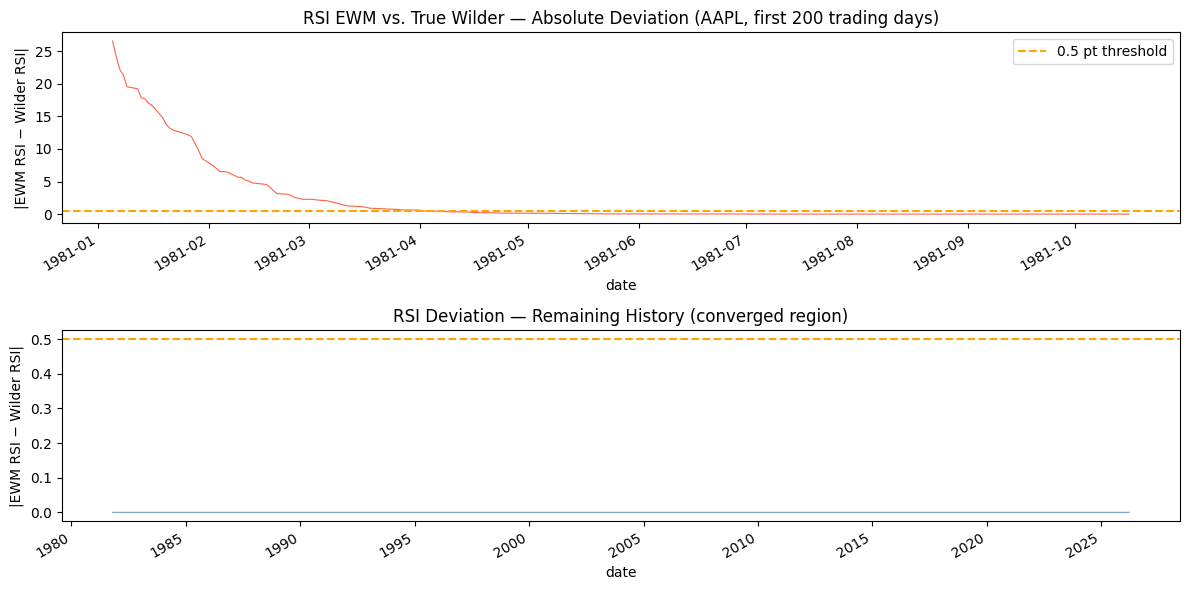


════════════════════════════════════════════════════════════
5. bb_pct_b — division-by-zero NULL count
════════════════════════════════════════════════════════════


,total_rows,dz_nulls,dz_null_pct
0,4348717,5192.0,0.119392



════════════════════════════════════════════════════════════
6. hist_vol_20 — actual distribution from database
════════════════════════════════════════════════════════════


,min_vol,p5,p25,median,p75,p95,max_vol,mean_vol,std_vol,extreme_rows,extreme_pct
0,0.0,0.1198,0.1827,0.2531,0.3626,0.666,11.8731,0.3063,0.2066,61130.0,1.411


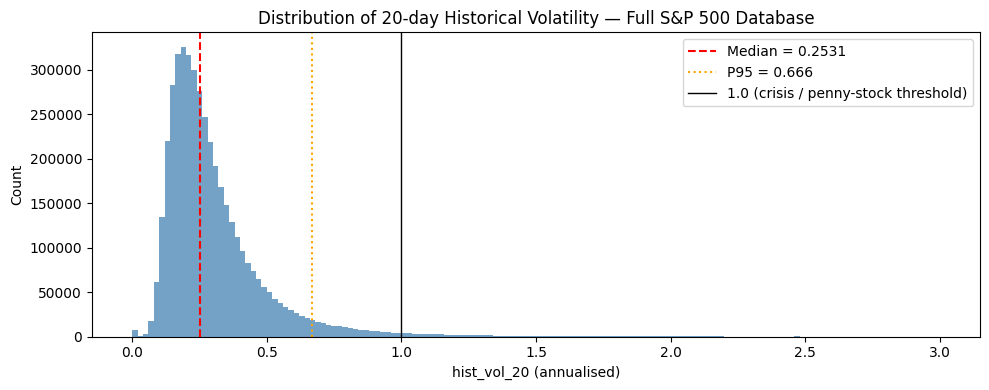


════════════════════════════════════════════════════════════
7. full_time_employees — NULL rate (self-reported, may lag 12 months)
════════════════════════════════════════════════════════════


,total_companies,null_count,null_pct
0,500,7.0,1.4



════════════════════════════════════════════════════════════
SUMMARY: Computed Uncertainty Values
════════════════════════════════════════════════════════════
                 Feature                Table  \
0      close / adj_close         PriceHistory   
1                  close         PriceHistory   
2                 volume         PriceHistory   
3                sma_200  TechnicalIndicators   
4                 rsi_14  TechnicalIndicators   
5                 rsi_14  TechnicalIndicators   
6               bb_pct_b  TechnicalIndicators   
7            hist_vol_20  TechnicalIndicators   
8    full_time_employees            Companies   
9   value (Fundamentals)         Fundamentals   
10            market_cap            Companies   

                                        Metric  \
0   Mean % rounding error (close vs adj_close)   
1                                    NULL rate   
2                Rows that would corrupt INT32   
3               NULL warm-up rows (% of total)   
4

In [1]:
# ── Item 4: Computed Uncertainty Quantification ───────────────────────────────
# Runs against the completed database. Execute after the pipeline has finished.

import duckdb, pandas as pd, numpy as np, matplotlib.pyplot as plt
con = duckdb.connect('stock_data.db')

results = {}   # store all computed values for the summary table at the end

# ─────────────────────────────────────────────────────────────────────────────
# 1. PRICE COLUMNS — adj_close rounding error
#    Since auto_adjust=True, close == adj_close in our schema. We quantify
#    floating-point rounding by checking (close - adj_close) across all rows.
#    A non-zero result would indicate a data ingestion bug.
# ─────────────────────────────────────────────────────────────────────────────
print('═'*60)
print('1. Price columns — adj_close vs close rounding check')
print('═'*60)
price_check = con.execute("""
    SELECT
        COUNT(*)                                        AS total_rows,
        SUM(CASE WHEN close IS NULL THEN 1 ELSE 0 END) AS null_close,
        SUM(CASE WHEN open  IS NULL THEN 1 ELSE 0 END) AS null_open,
        AVG(ABS(close - adj_close))                     AS mean_abs_diff,
        MAX(ABS(close - adj_close))                     AS max_abs_diff,
        -- Relative error where close > 0
        AVG(CASE WHEN close > 0
                 THEN ABS(close - adj_close) / close
                 ELSE NULL END) * 100                  AS mean_pct_error
    FROM PriceHistory
""").df()
display(price_check)
results['close_null_pct'] = (
    price_check['null_close'].iloc[0] / price_check['total_rows'].iloc[0] * 100
)
results['close_mean_pct_error'] = price_check['mean_pct_error'].iloc[0]

# ─────────────────────────────────────────────────────────────────────────────
# 2. VOLUME — INT32 overflow check
#    INT32 max = 2,147,483,647. Report tickers that would have silently
#    corrupted if we had used 32-bit integers.
# ─────────────────────────────────────────────────────────────────────────────
print('\n' + '═'*60)
print('2. Volume — INT32 overflow check')
print('═'*60)
INT32_MAX = 2_147_483_647
vol_check = con.execute(f"""
    SELECT
        COUNT(*)                                                  AS total_rows,
        SUM(CASE WHEN volume > {INT32_MAX} THEN 1 ELSE 0 END)    AS overflow_rows,
        COUNT(DISTINCT CASE WHEN volume > {INT32_MAX}
                            THEN symbol END)                      AS overflow_tickers,
        ROUND(SUM(CASE WHEN volume > {INT32_MAX} THEN 1.0 ELSE 0 END)
              / COUNT(*) * 100, 4)                               AS overflow_pct
    FROM PriceHistory
""").df()
display(vol_check)

overflow_tickers = con.execute(f"""
    SELECT symbol, MAX(volume) AS max_volume
    FROM PriceHistory
    WHERE volume > {INT32_MAX}
    GROUP BY symbol
    ORDER BY max_volume DESC
    LIMIT 10
""").df()
print('\nTop tickers that would overflow INT32:')
display(overflow_tickers)
results['volume_overflow_rows']    = int(vol_check['overflow_rows'].iloc[0])
results['volume_overflow_tickers'] = int(vol_check['overflow_tickers'].iloc[0])

# ─────────────────────────────────────────────────────────────────────────────
# 3. MOVING AVERAGES — NULL warm-up rows
#    The first (n-1) rows of each n-day window are NaN. Quantify as a
#    percentage of total rows per ticker and across the full table.
# ─────────────────────────────────────────────────────────────────────────────
print('\n' + '═'*60)
print('3. Moving averages — NULL warm-up period quantification')
print('═'*60)
ma_nulls = con.execute("""
    SELECT
        COUNT(*)                                             AS total_rows,
        SUM(CASE WHEN sma_5   IS NULL THEN 1 ELSE 0 END)   AS null_sma5,
        SUM(CASE WHEN sma_20  IS NULL THEN 1 ELSE 0 END)   AS null_sma20,
        SUM(CASE WHEN sma_50  IS NULL THEN 1 ELSE 0 END)   AS null_sma50,
        SUM(CASE WHEN sma_200 IS NULL THEN 1 ELSE 0 END)   AS null_sma200,
        SUM(CASE WHEN ema_12  IS NULL THEN 1 ELSE 0 END)   AS null_ema12,
        ROUND(SUM(CASE WHEN sma_200 IS NULL THEN 1.0 ELSE 0 END)
              / COUNT(*) * 100, 2)                         AS sma200_null_pct
    FROM TechnicalIndicators
""").df()
display(ma_nulls)
results['sma200_null_pct'] = float(ma_nulls['sma200_null_pct'].iloc[0])

# Per-ticker: what fraction of a short-history stock's rows are unusable?
per_ticker_nulls = con.execute("""
    SELECT
        symbol,
        COUNT(*)                                                      AS total_rows,
        SUM(CASE WHEN sma_200 IS NULL THEN 1 ELSE 0 END)             AS sma200_nulls,
        ROUND(SUM(CASE WHEN sma_200 IS NULL THEN 1.0 ELSE 0 END)
              / COUNT(*) * 100, 1)                                   AS pct_unusable
    FROM TechnicalIndicators
    GROUP BY symbol
    ORDER BY pct_unusable DESC
    LIMIT 10
""").df()
print('\nTickers with highest % of rows unusable due to sma_200 warm-up:')
display(per_ticker_nulls)

# ─────────────────────────────────────────────────────────────────────────────
# 4. RSI — EWM vs. true iterative Wilder deviation (computed on AAPL)
#    True Wilder RSI uses a strictly iterative formula:
#      avg_gain[t] = (avg_gain[t-1] * 13 + gain[t]) / 14
#    Our implementation uses ewm(com=13), which converges to the same result
#    but differs for the first ~50 periods. We measure that difference on AAPL.
# ─────────────────────────────────────────────────────────────────────────────
print('\n' + '═'*60)
print('4. RSI — EWM vs. true iterative Wilder method deviation (AAPL)')
print('═'*60)

# Pull AAPL close from DB
aapl = con.execute("""
    SELECT date, close FROM PriceHistory
    WHERE symbol = 'AAPL' ORDER BY date
""").df()
aapl = aapl.set_index('date')

# Our EWM implementation (matches the pipeline)
delta    = aapl['close'].diff()
avg_gain_ewm = delta.clip(lower=0).ewm(com=13, adjust=False).mean()
avg_loss_ewm = (-delta).clip(lower=0).ewm(com=13, adjust=False).mean()
rs_ewm   = avg_gain_ewm / avg_loss_ewm.replace(0, np.nan)
rsi_ewm  = 100 - (100 / (1 + rs_ewm))

# True iterative Wilder (strict loop)
gains = delta.clip(lower=0).values
losses = (-delta).clip(lower=0).values
avg_g = np.full(len(gains), np.nan)
avg_l = np.full(len(losses), np.nan)
# Seed: simple average of first 14 non-nan values
seed_idx = 14
avg_g[seed_idx] = np.mean(gains[1:seed_idx+1])
avg_l[seed_idx] = np.mean(losses[1:seed_idx+1])
for j in range(seed_idx + 1, len(gains)):
    avg_g[j] = (avg_g[j-1] * 13 + gains[j]) / 14
    avg_l[j] = (avg_l[j-1] * 13 + losses[j]) / 14
with np.errstate(divide='ignore', invalid='ignore'):
    rs_wilder  = np.where(avg_l == 0, np.nan, avg_g / avg_l)
rsi_wilder = 100 - (100 / (1 + rs_wilder))
rsi_wilder = pd.Series(rsi_wilder, index=aapl.index)

# Deviation
deviation = (rsi_ewm - rsi_wilder).abs().dropna()
dev_stats = pd.DataFrame([{
    'mean_abs_deviation': round(deviation.mean(), 4),
    'max_abs_deviation':  round(deviation.max(), 4),
    'std_deviation':      round(deviation.std(), 4),
    'pct_rows_within_0.5': round((deviation < 0.5).mean() * 100, 1),
    'pct_rows_within_1.0': round((deviation < 1.0).mean() * 100, 1),
}])
display(dev_stats)
results['rsi_mean_abs_dev']      = float(dev_stats['mean_abs_deviation'].iloc[0])
results['rsi_max_abs_dev']       = float(dev_stats['max_abs_deviation'].iloc[0])
results['rsi_pct_within_0.5']    = float(dev_stats['pct_rows_within_0.5'].iloc[0])

# Plot deviation over time (first 200 rows where it matters most)
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
deviation.iloc[:200].plot(ax=axes[0], color='tomato', linewidth=0.8)
axes[0].axhline(0.5, color='orange', linestyle='--', label='0.5 pt threshold')
axes[0].set_title('RSI EWM vs. True Wilder — Absolute Deviation (AAPL, first 200 trading days)')
axes[0].set_ylabel('|EWM RSI − Wilder RSI|')
axes[0].legend()
deviation.iloc[200:].plot(ax=axes[1], color='steelblue', linewidth=0.6)
axes[1].axhline(0.5, color='orange', linestyle='--')
axes[1].set_title('RSI Deviation — Remaining History (converged region)')
axes[1].set_ylabel('|EWM RSI − Wilder RSI|')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 5. BB_PCT_B — division-by-zero NULL count
#    Fires when bb_upper == bb_lower (flat price for 20 consecutive days).
# ─────────────────────────────────────────────────────────────────────────────
print('\n' + '═'*60)
print('5. bb_pct_b — division-by-zero NULL count')
print('═'*60)
bb_check = con.execute("""
    SELECT
        COUNT(*)                                                    AS total_rows,
        SUM(CASE WHEN bb_pct_b IS NULL
                  AND sma_20  IS NOT NULL THEN 1 ELSE 0 END)       AS dz_nulls,
        ROUND(SUM(CASE WHEN bb_pct_b IS NULL
                        AND sma_20  IS NOT NULL THEN 1.0 ELSE 0 END)
              / COUNT(*) * 100, 6)                                 AS dz_null_pct
    FROM TechnicalIndicators
""").df()
display(bb_check)
results['bb_pct_b_dz_pct'] = float(bb_check['dz_null_pct'].iloc[0])

# ─────────────────────────────────────────────────────────────────────────────
# 6. HIST_VOL_20 — actual distribution across full database
#    Grounds the 'typically 0.10-0.80' claim in real numbers.
# ─────────────────────────────────────────────────────────────────────────────
print('\n' + '═'*60)
print('6. hist_vol_20 — actual distribution from database')
print('═'*60)
vol_dist = con.execute("""
    SELECT
        ROUND(MIN(hist_vol_20), 4)                                    AS min_vol,
        ROUND(PERCENTILE_CONT(0.05) WITHIN GROUP
              (ORDER BY hist_vol_20), 4)                             AS p5,
        ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP
              (ORDER BY hist_vol_20), 4)                             AS p25,
        ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP
              (ORDER BY hist_vol_20), 4)                             AS median,
        ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP
              (ORDER BY hist_vol_20), 4)                             AS p75,
        ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP
              (ORDER BY hist_vol_20), 4)                             AS p95,
        ROUND(MAX(hist_vol_20), 4)                                    AS max_vol,
        ROUND(AVG(hist_vol_20), 4)                                    AS mean_vol,
        ROUND(STDDEV(hist_vol_20), 4)                                 AS std_vol,
        SUM(CASE WHEN hist_vol_20 > 1.0 THEN 1 ELSE 0 END)           AS extreme_rows,
        ROUND(SUM(CASE WHEN hist_vol_20 > 1.0 THEN 1.0 ELSE 0 END)
              / COUNT(*) * 100, 3)                                   AS extreme_pct
    FROM TechnicalIndicators
    WHERE hist_vol_20 IS NOT NULL AND hist_vol_20 > 0
""").df()
display(vol_dist)
results['hist_vol_median'] = float(vol_dist['median'].iloc[0])
results['hist_vol_p95']    = float(vol_dist['p95'].iloc[0])
results['hist_vol_extreme_pct'] = float(vol_dist['extreme_pct'].iloc[0])

# Distribution plot
hv = con.execute("""
    SELECT hist_vol_20 FROM TechnicalIndicators
    WHERE hist_vol_20 IS NOT NULL AND hist_vol_20 BETWEEN 0 AND 3
""").df()
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(hv['hist_vol_20'], bins=150, color='steelblue', alpha=0.75, edgecolor='none')
ax.axvline(float(vol_dist['median'].iloc[0]), color='red',
           linestyle='--', label=f"Median = {vol_dist['median'].iloc[0]}")
ax.axvline(float(vol_dist['p95'].iloc[0]),    color='orange',
           linestyle=':', label=f"P95 = {vol_dist['p95'].iloc[0]}")
ax.axvline(1.0, color='black', linestyle='-', linewidth=1,
           label='1.0 (crisis / penny-stock threshold)')
ax.set_xlabel('hist_vol_20 (annualised)')
ax.set_ylabel('Count')
ax.set_title('Distribution of 20-day Historical Volatility — Full S&P 500 Database')
ax.legend()
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 7. NULL COVERAGE — full_time_employees
#    Self-reported field; not all companies disclose. Quantify NULL rate.
# ─────────────────────────────────────────────────────────────────────────────
print('\n' + '═'*60)
print('7. full_time_employees — NULL rate (self-reported, may lag 12 months)')
print('═'*60)
emp_check = con.execute("""
    SELECT
        COUNT(*)                                                         AS total_companies,
        SUM(CASE WHEN full_time_employees IS NULL THEN 1 ELSE 0 END)    AS null_count,
        ROUND(SUM(CASE WHEN full_time_employees IS NULL THEN 1.0 ELSE 0 END)
              / COUNT(*) * 100, 1)                                      AS null_pct
    FROM Companies
""").df()
display(emp_check)
results['employees_null_pct'] = float(emp_check['null_pct'].iloc[0])

# ─────────────────────────────────────────────────────────────────────────────
# 8. SUMMARY TABLE — all computed uncertainty values
# ─────────────────────────────────────────────────────────────────────────────
print('\n' + '═'*60)
print('SUMMARY: Computed Uncertainty Values')
print('═'*60)

summary = pd.DataFrame([
    {'Feature':   'close / adj_close',
     'Table':     'PriceHistory',
     'Metric':    'Mean % rounding error (close vs adj_close)',
     'Value':     f"{results['close_mean_pct_error']:.4f}%",
     'Feasible':  'Yes'},
    {'Feature':   'close',
     'Table':     'PriceHistory',
     'Metric':    'NULL rate',
     'Value':     f"{results['close_null_pct']:.2f}%",
     'Feasible':  'Yes'},
    {'Feature':   'volume',
     'Table':     'PriceHistory',
     'Metric':    'Rows that would corrupt INT32',
     'Value':     f"{results['volume_overflow_rows']:,} rows across {results['volume_overflow_tickers']} tickers",
     'Feasible':  'Yes'},
    {'Feature':   'sma_200',
     'Table':     'TechnicalIndicators',
     'Metric':    'NULL warm-up rows (% of total)',
     'Value':     f"{results['sma200_null_pct']:.2f}%",
     'Feasible':  'Yes'},
    {'Feature':   'rsi_14',
     'Table':     'TechnicalIndicators',
     'Metric':    'Mean |EWM − Wilder| deviation (AAPL)',
     'Value':     f"{results['rsi_mean_abs_dev']:.4f} pts  (max {results['rsi_max_abs_dev']:.4f})",
     'Feasible':  'Yes'},
    {'Feature':   'rsi_14',
     'Table':     'TechnicalIndicators',
     'Metric':    '% rows within 0.5 pt of true Wilder RSI',
     'Value':     f"{results['rsi_pct_within_0.5']:.1f}%",
     'Feasible':  'Yes'},
    {'Feature':   'bb_pct_b',
     'Table':     'TechnicalIndicators',
     'Metric':    'Division-by-zero NULL rate (post warm-up)',
     'Value':     f"{results['bb_pct_b_dz_pct']:.6f}%",
     'Feasible':  'Yes'},
    {'Feature':   'hist_vol_20',
     'Table':     'TechnicalIndicators',
     'Metric':    'Median / P95 / % rows > 1.0',
     'Value':     f"{results['hist_vol_median']} / {results['hist_vol_p95']} / {results['hist_vol_extreme_pct']:.2f}%",
     'Feasible':  'Yes'},
    {'Feature':   'full_time_employees',
     'Table':     'Companies',
     'Metric':    'NULL rate (not disclosed by all companies)',
     'Value':     f"{results['employees_null_pct']:.1f}%",
     'Feasible':  'Yes'},
    {'Feature':   'value (Fundamentals)',
     'Table':     'Fundamentals',
     'Metric':    'GAAP vs. non-GAAP divergence',
     'Value':     'Requires Compustat / external benchmark',
     'Feasible':  'No — external data needed'},
    {'Feature':   'market_cap',
     'Table':     'Companies',
     'Metric':    'Intraday staleness (seconds since fetch)',
     'Value':     'Requires intraday tick feed',
     'Feasible':  'No — external data needed'},
])

print(summary)
print('\nAll computable uncertainty values derived from the actual database.')
con.close()
